In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from nltk.tokenize import word_tokenize, sent_tokenize
import re

In [3]:
# Load the news datasets
news_df = pd.read_csv('cleaned_dataset/combined_news.csv')

In [ ]:
# Create space-flag columns for a given text column
def add_space_flags(df, col_name: str, label: str | None = None):
    if col_name not in df.columns:
        raise KeyError(f"Column '{col_name}' not found in dataframe")
    s = df[col_name].astype('string')
    lbl = label or col_name
    df[f"{lbl}_has_leading_space"] = s.str.startswith(' ', na=False)
    df[f"{lbl}_has_trailing_space"] = s.str.endswith(' ', na=False)


In [ ]:
# Apply the function to add space flags for 'title' and 'text'
add_space_flags(news_df, 'title', 'title')
add_space_flags(news_df, 'text', 'text')


In [ ]:
# Check the updated dataframe
news_df.head()

,title,text,subject,date,year,label,cleaned_title,cleaned_text,title_has_leading_space,title_has_trailing_space,text_has_leading_space,text_has_trailing_space
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,2017-12-31,2017.0,False,donald trump sends out embarrassing new year’s...,donald trump wish american happy new year leav...,True,False,False,False
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,2017-12-31,2017.0,False,drunk bragging trump staffer started russian c...,house intelligence committee chairman devin nu...,True,False,False,False
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,2017-12-30,2017.0,False,sheriff david clarke becomes an internet joke ...,friday revealed former milwaukee sheriff david...,True,False,False,False
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,2017-12-29,2017.0,False,trump is so obsessed he even has obama’s name ...,christmas day donald trump announced would bac...,True,False,False,False
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,2017-12-25,2017.0,False,pope francis just called out donald trump duri...,pope francis used annual christmas day message...,True,False,False,False


In [ ]:
# Add text statistics features
s = news_df['text'].astype('string').fillna('')
news_df['number_of_characters'] = s.str.len()
news_df['number_of_words'] = s.apply(lambda x: len(word_tokenize(x)))
news_df['number_of_sentences'] = s.apply(lambda x: len(sent_tokenize(x)))
news_df['url_count'] = s.apply(lambda x: len(re.findall(r'https?://\S+', x)))

cs = news_df['cleaned_text'].astype('string').fillna('')
news_df['unique_words'] = cs.apply(lambda x: len(set(word_tokenize(x))))

In [15]:
# Save the feature engineered dataset
# news_df.to_csv('cleaned_dataset/featureengineered_news.csv', index=False)

In [ ]:
# Load the feature engineered dataset that has been saved
news_df = pd.read_csv('cleaned_dataset/featureengineered_news.csv')
news_df.head()

,title,text,subject,date,year,label,cleaned_title,cleaned_text,title_has_leading_space,title_has_trailing_space,text_has_leading_space,text_has_trailing_space,number_of_characters,number_of_words,number_of_sentences,url_count,unique_words
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,2017-12-31,2017.0,False,donald trump sends out embarrassing new year’s...,donald trump wish american happy new year leav...,True,False,False,False,2893,599,28,0,158
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,2017-12-31,2017.0,False,drunk bragging trump staffer started russian c...,house intelligence committee chairman devin nu...,True,False,False,False,1898,331,11,0,130
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,2017-12-30,2017.0,False,sheriff david clarke becomes an internet joke ...,friday revealed former milwaukee sheriff david...,True,False,False,False,3597,689,25,1,207
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,2017-12-29,2017.0,False,trump is so obsessed he even has obama’s name ...,christmas day donald trump announced would bac...,True,False,False,False,2774,519,15,4,162
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,2017-12-25,2017.0,False,pope francis just called out donald trump duri...,pope francis used annual christmas day message...,True,False,False,False,2346,458,19,0,154


C:\Users\vewiz\AppData\Local\Temp\ipykernel_45600\865320605.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[row, col].boxplot([fake_data, real_data], labels=['Fake', 'Real'],
C:\Users\vewiz\AppData\Local\Temp\ipykernel_45600\865320605.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[row, col].boxplot([fake_data, real_data], labels=['Fake', 'Real'],
C:\Users\vewiz\AppData\Local\Temp\ipykernel_45600\865320605.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[row, col].boxplot([fake_data, real_data], labels=['Fake', 'Real'],
C:\Users\vewiz\AppData\Local\Temp\ipykernel_45600\865320605.py:15: Mat

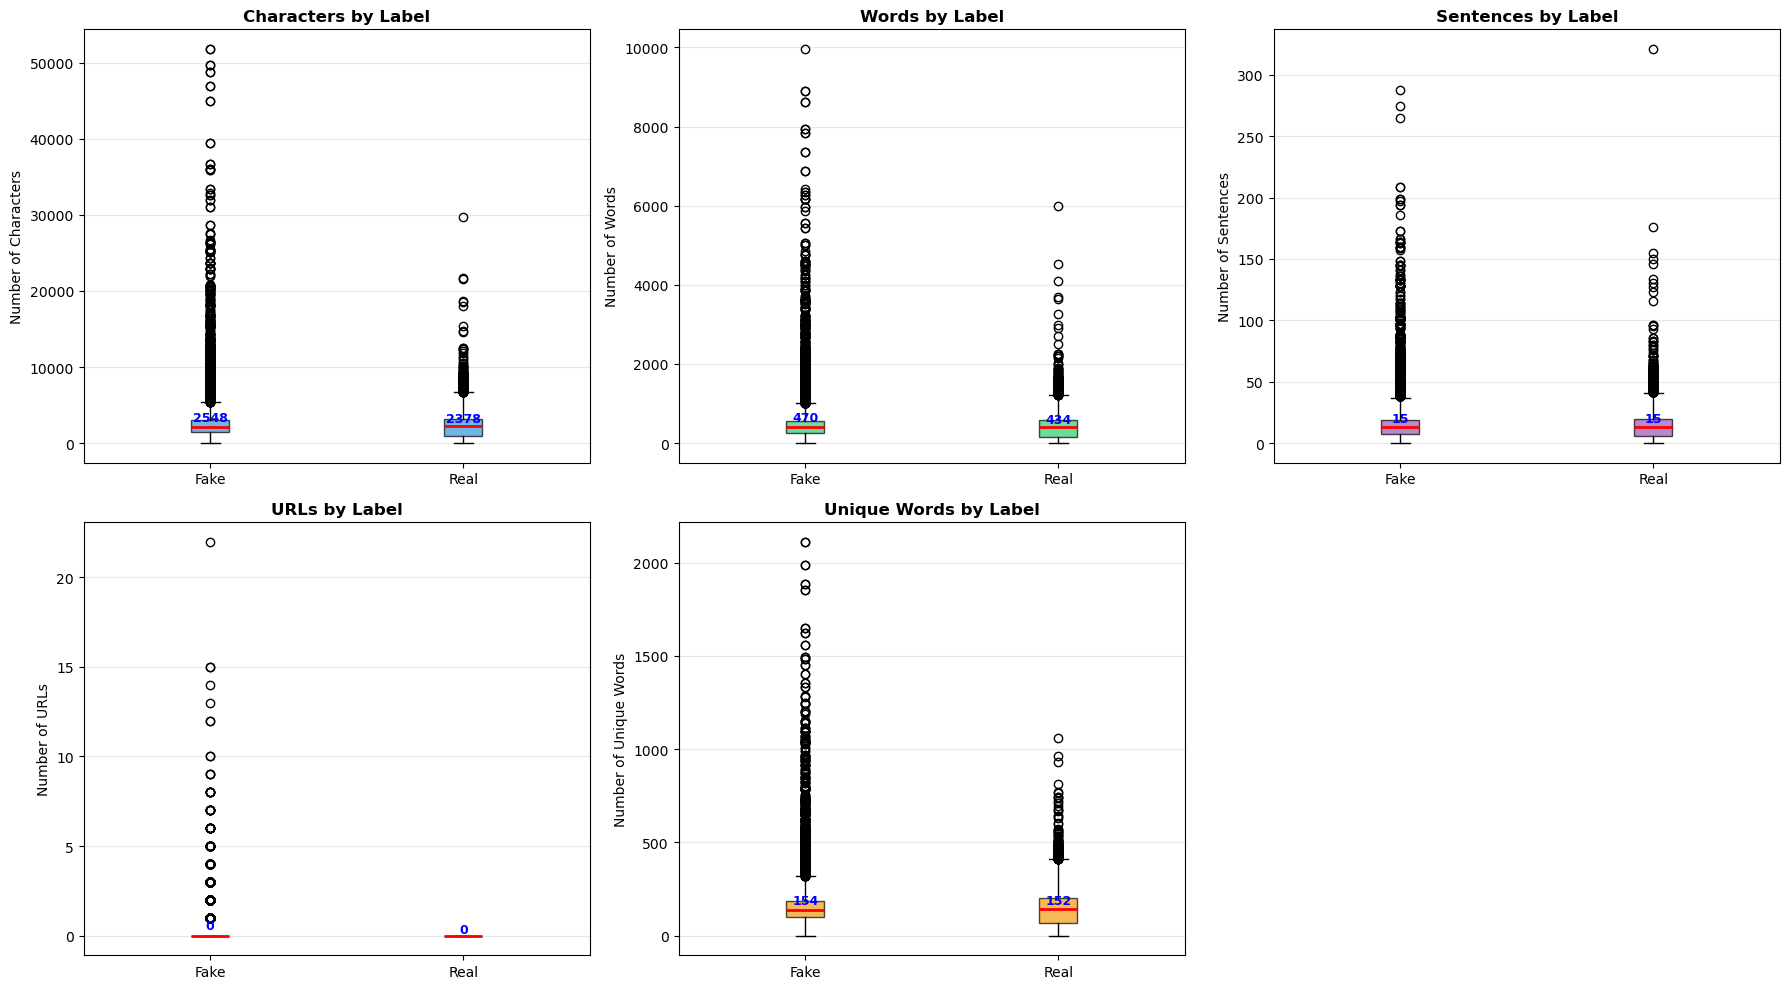

In [ ]:
# Create box plots to visualize the distributions of features
# Comparison by label (Fake vs Real)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

features = ['number_of_characters', 'number_of_words', 'number_of_sentences', 'url_count', 'unique_words']
titles = ['Characters', 'Words', 'Sentences', 'URLs', 'Unique Words']
colors = ['#3498db', '#2ecc71', '#9b59b6', '#e74c3c', '#f39c12']

for idx, (feature, title, color) in enumerate(zip(features, titles, colors)):
    row = idx // 3
    col = idx % 3
    
    fake_data = news_df[news_df['label'] == 0][feature]
    real_data = news_df[news_df['label'] == 1][feature]
    
    axes[row, col].boxplot([fake_data, real_data], labels=['Fake', 'Real'],
                           patch_artist=True,
                           boxprops=dict(facecolor=color, alpha=0.7),
                           medianprops=dict(color='red', linewidth=2))
    axes[row, col].set_title(f'{title} by Label', fontsize=12, fontweight='bold')
    axes[row, col].set_ylabel(f'Number of {title}')
    axes[row, col].grid(axis='y', alpha=0.3)
    
    # Add mean values
    fake_mean = fake_data.mean()
    real_mean = real_data.mean()
    axes[row, col].text(1, fake_mean, f'{fake_mean:.0f}', ha='center', va='bottom', 
                       fontweight='bold', color='blue', fontsize=9)
    axes[row, col].text(2, real_mean, f'{real_mean:.0f}', ha='center', va='bottom', 
                       fontweight='bold', color='blue', fontsize=9)

# Remove the empty subplot
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

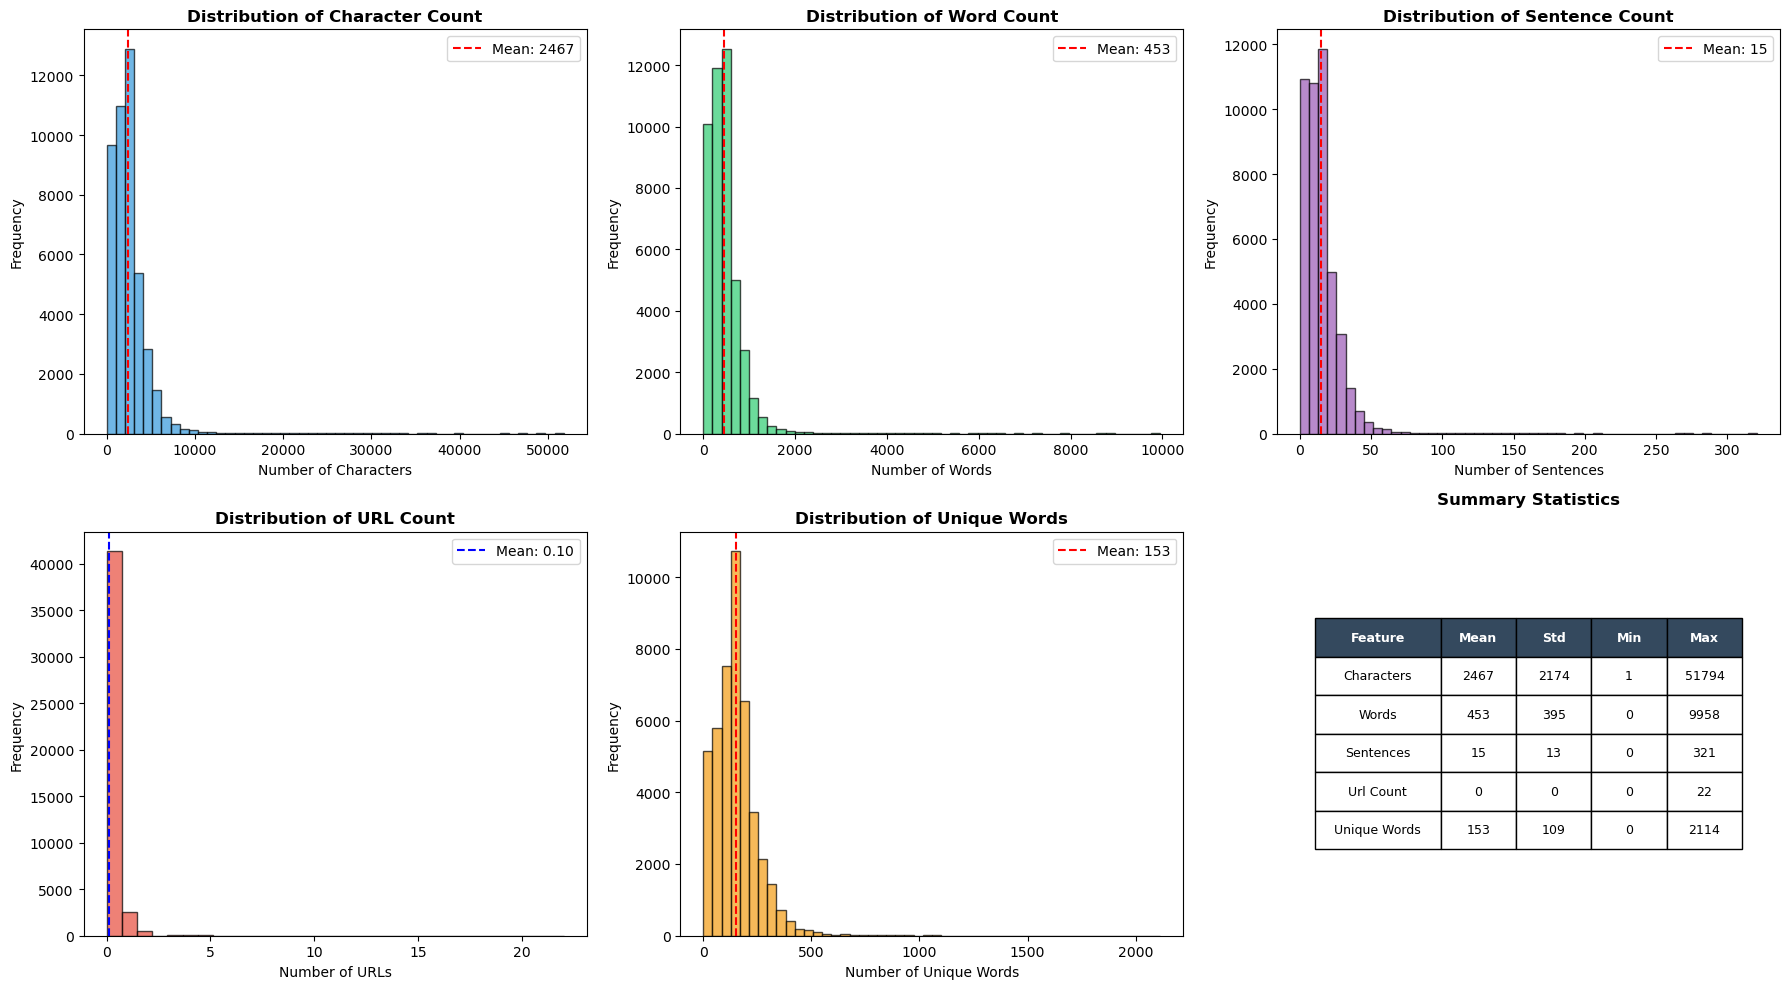

In [ ]:
# Visualize the distribution of text statistics
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Number of characters
axes[0, 0].hist(news_df['number_of_characters'], bins=50, color='#3498db', edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Distribution of Character Count', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Number of Characters')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].axvline(news_df['number_of_characters'].mean(), color='red', linestyle='--', 
                    label=f'Mean: {news_df["number_of_characters"].mean():.0f}')
axes[0, 0].legend()

# Number of words
axes[0, 1].hist(news_df['number_of_words'], bins=50, color='#2ecc71', edgecolor='black', alpha=0.7)
axes[0, 1].set_title('Distribution of Word Count', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Number of Words')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].axvline(news_df['number_of_words'].mean(), color='red', linestyle='--', 
                    label=f'Mean: {news_df["number_of_words"].mean():.0f}')
axes[0, 1].legend()

# Number of sentences
axes[0, 2].hist(news_df['number_of_sentences'], bins=50, color='#9b59b6', edgecolor='black', alpha=0.7)
axes[0, 2].set_title('Distribution of Sentence Count', fontsize=12, fontweight='bold')
axes[0, 2].set_xlabel('Number of Sentences')
axes[0, 2].set_ylabel('Frequency')
axes[0, 2].axvline(news_df['number_of_sentences'].mean(), color='red', linestyle='--', 
                    label=f'Mean: {news_df["number_of_sentences"].mean():.0f}')
axes[0, 2].legend()

# URL count
axes[1, 0].hist(news_df['url_count'], bins=30, color='#e74c3c', edgecolor='black', alpha=0.7)
axes[1, 0].set_title('Distribution of URL Count', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Number of URLs')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].axvline(news_df['url_count'].mean(), color='blue', linestyle='--', 
                    label=f'Mean: {news_df["url_count"].mean():.2f}')
axes[1, 0].legend()

# Unique words
axes[1, 1].hist(news_df['unique_words'], bins=50, color='#f39c12', edgecolor='black', alpha=0.7)
axes[1, 1].set_title('Distribution of Unique Words', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Number of Unique Words')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].axvline(news_df['unique_words'].mean(), color='red', linestyle='--', 
                    label=f'Mean: {news_df["unique_words"].mean():.0f}')
axes[1, 1].legend()

# Summary statistics table
axes[1, 2].axis('off')
summary_stats = news_df[['number_of_characters', 'number_of_words', 'number_of_sentences', 
                          'url_count', 'unique_words']].describe().round(2)
table_data = []
table_data.append(['Feature', 'Mean', 'Std', 'Min', 'Max'])
for col in summary_stats.columns:
    table_data.append([
        col.replace('number_of_', '').replace('_', ' ').title(),
        f"{summary_stats.loc['mean', col]:.0f}",
        f"{summary_stats.loc['std', col]:.0f}",
        f"{summary_stats.loc['min', col]:.0f}",
        f"{summary_stats.loc['max', col]:.0f}"
    ])

table = axes[1, 2].table(cellText=table_data, cellLoc='center', loc='center',
                         colWidths=[0.25, 0.15, 0.15, 0.15, 0.15])
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 2)
for i in range(len(table_data[0])):
    table[(0, i)].set_facecolor('#34495e')
    table[(0, i)].set_text_props(weight='bold', color='white')

axes[1, 2].set_title('Summary Statistics', fontsize=12, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

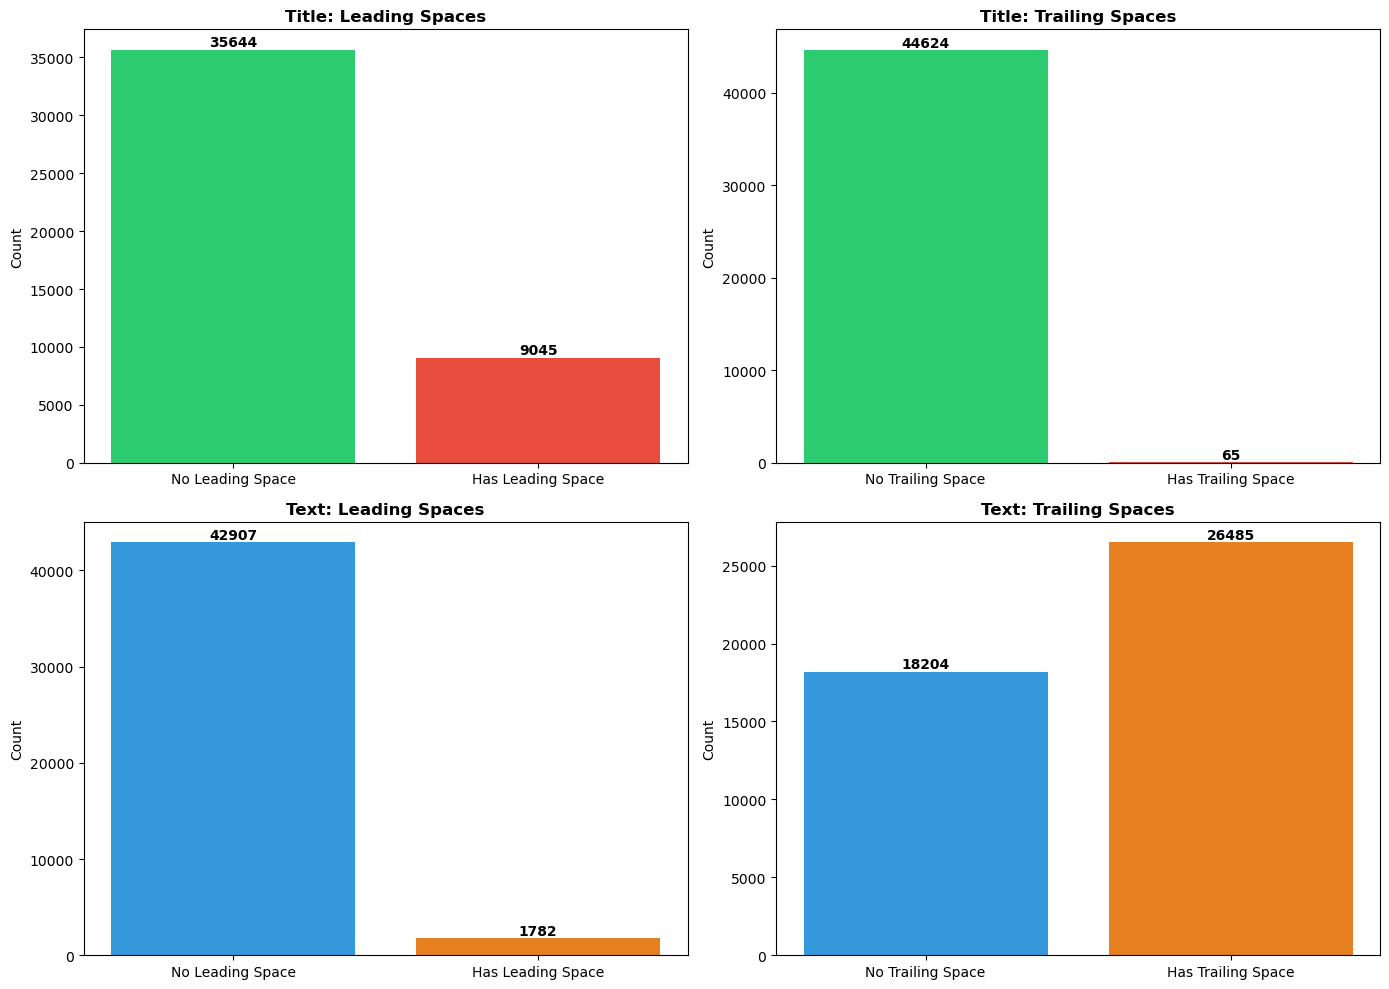

In [ ]:
# Visualizations cont.

# Count leading and trailing spaces
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Title leading/trailing spaces
title_leading = news_df['title_has_leading_space'].value_counts()
title_trailing = news_df['title_has_trailing_space'].value_counts()

axes[0, 0].bar(['No Leading Space', 'Has Leading Space'], 
               [title_leading.get(False, 0), title_leading.get(True, 0)],
               color=['#2ecc71', '#e74c3c'])
axes[0, 0].set_title('Title: Leading Spaces', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Count')
for i, v in enumerate([title_leading.get(False, 0), title_leading.get(True, 0)]):
    axes[0, 0].text(i, v + 50, str(v), ha='center', va='bottom', fontweight='bold')

axes[0, 1].bar(['No Trailing Space', 'Has Trailing Space'], 
               [title_trailing.get(False, 0), title_trailing.get(True, 0)],
               color=['#2ecc71', '#e74c3c'])
axes[0, 1].set_title('Title: Trailing Spaces', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Count')
for i, v in enumerate([title_trailing.get(False, 0), title_trailing.get(True, 0)]):
    axes[0, 1].text(i, v + 50, str(v), ha='center', va='bottom', fontweight='bold')

# Text leading/trailing spaces
text_leading = news_df['text_has_leading_space'].value_counts()
text_trailing = news_df['text_has_trailing_space'].value_counts()

axes[1, 0].bar(['No Leading Space', 'Has Leading Space'], 
               [text_leading.get(False, 0), text_leading.get(True, 0)],
               color=['#3498db', '#e67e22'])
axes[1, 0].set_title('Text: Leading Spaces', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Count')
for i, v in enumerate([text_leading.get(False, 0), text_leading.get(True, 0)]):
    axes[1, 0].text(i, v + 50, str(v), ha='center', va='bottom', fontweight='bold')

axes[1, 1].bar(['No Trailing Space', 'Has Trailing Space'], 
               [text_trailing.get(False, 0), text_trailing.get(True, 0)],
               color=['#3498db', '#e67e22'])
axes[1, 1].set_title('Text: Trailing Spaces', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Count')
for i, v in enumerate([text_trailing.get(False, 0), text_trailing.get(True, 0)]):
    axes[1, 1].text(i, v + 50, str(v), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()